# Análise Exploratória e Qualidade de Dados – Vendas de E-commerce

## Contexto de Negócio
Este projeto analisa uma base de dados de vendas de um e-commerce, proveniente de um sistema de CRM operacional. 
O objetivo principal é avaliar a qualidade dos dados transacionais, identificar problemas estruturais 
(inconsistências, duplicidades e dados faltantes) e preparar a base para análises confiáveis que apoiem 
decisões estratégicas nas áreas de marketing, operações e comercial.

## Objetivos
- Avaliar a qualidade da base de dados (dados faltantes, inconsistências, duplicidades e outliers).
- Definir e executar estratégias de tratamento e padronização dos dados.
- Gerar métricas e insights de performance de vendas para apoio à tomada de decisão.
---

# 1. Imports

In [107]:
import pandas as pd
import numpy as np

Carregamento da base bruta (raw) de vendas proveniente do CRM.

In [20]:
df = pd.read_csv("../data/raw/vendas_loja_crm_sujo.csv")

Visualização inicial da base para entendimento do schema e inspeção preliminar dos dados.

In [21]:
df.head()

,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento
0,2127,2023-10-02 10:11:55.677118076,Camisa D,Roupas,80,1,0.16,94.08,Rio de Janeiro,Pix
1,2460,2024-01-04 06:53:04.523015344,Fone C,Eletrônicos,300,1,0.01,415.80,SP,Cartão de Crédito
2,1861,2023-08-09 19:58:52.755170112,Camisa D,NaN,"R$ 80,00",2,0.07,148.80,São Paulo,Cartão de Débito
3,2295,2023-10-21 05:17:00.680453636,Camisa D,Roupas,80,3,0.05,319.20,Belo Horizonte,Cartão de Crédito
4,2131,2023-10-09 00:00:00.000000000,Notebook B,Eletrônicos,3500,3,0.03,14259.00,Curitiba,Cartão de Crédito


In [110]:
print(f"A base contém {df.shape[0]} registros distribuídos em {df.shape[1]} colunas.")

A base contém 12000 registros distribuídos em 10 colunas.


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID da Venda         12000 non-null  int64  
 1   Data da Venda       12000 non-null  str    
 2   Produto             12000 non-null  str    
 3   Categoria           11519 non-null  str    
 4   Preço Unitário      12000 non-null  str    
 5   Quantidade Vendida  12000 non-null  int64  
 6   Desconto            12000 non-null  float64
 7   Valor Total         12000 non-null  float64
 8   Localização         11533 non-null  str    
 9   Forma de Pagamento  11517 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 937.6 KB


**Observações iniciais sobre o schema da base:**
A inspeção do schema indica a presença de colunas críticas tipadas como texto (Data da Venda e Preço Unitário), além de valores ausentes em colunas relevantes para segmentação de negócio (Categoria, Localização e Forma de Pagamento). Esses pontos serão analisados em detalhe na seção de diagnóstico de qualidade dos dados.

# 2. Dicionário de Dados (Data Dictionary)

A tabela abaixo documenta o significado de cada coluna presente na base de dados de vendas do e-commerce, 
incluindo regras de negócio esperadas e o uso analítico de cada campo. Este dicionário define o contrato 
semântico dos dados e serve como referência para o diagnóstico de qualidade e para as etapas subsequentes 
de tratamento dos dados.

| Nome da Coluna        | Descrição de Negócio                                                                 | Tipo Esperado            | Regra de Negócio / Validação Esperada                                                                 | Uso Analítico                              | Observações de Qualidade (inicial) |
|----------------------|----------------------------------------------------------------------------------------|--------------------------|--------------------------------------------------------------------------------------------------------|--------------------------------------------|------------------------------------|
| ID da Venda          | Identificador único da transação de venda                                               | Inteiro (ID)             | Deve ser único por transação; não deve ser nulo                                                        | Rastreabilidade; contagem de pedidos        | Presença de duplicidade de IDs e registros duplicados na base. |
| Data da Venda        | Data e hora em que a venda foi concluída                                                | Data / Datetime          | Não deve ser nula; deve representar um timestamp válido                                                | Análises temporais; sazonalidade            | Coluna tipada como string; conversão para datetime necessária. |
| Produto              | Nome do produto vendido                                                                 | Categórico (string)      | Deve pertencer ao catálogo oficial de produtos                                                         | Segmentação por produto                    | Sem problemas relevantes de qualidade identificados. |
| Categoria            | Categoria do produto                                                                    | Categórico (string)      | Deve pertencer a um conjunto finito e padronizado de categorias válidas                                 | Análises por categoria                     | Presença de valores ausentes em parte dos registros. |
| Preço Unitário       | Preço unitário do produto no momento da venda                                           | Numérico (float)         | Deve ser positivo                                                                                       | Cálculo de receita; ticket médio           | Coluna tipada como string; requer limpeza e conversão para numérico. |
| Quantidade Vendida   | Quantidade de unidades do produto vendidas na transação                                 | Numérico (inteiro)       | Deve ser inteiro positivo; valores extremos devem ser avaliados quanto à plausibilidade operacional     | Volume de vendas; demanda                  | Identificados outliers não plausíveis associados a inconsistências financeiras. |
| Desconto             | Percentual de desconto aplicado sobre o valor unitário                                  | Numérico (float, 0–1)    | Deve estar entre 0 e 1 (ou 0% e 100%)                                                                    | Avaliação de política de descontos         | Valores dentro do intervalo esperado; presença de descontos extremos (até 90%). |
| Valor Total          | Valor total pago na transação após aplicação de desconto                                 | Numérico (float)         | Deve ser consistente com: preço unitário × quantidade × (1 − desconto)                                  | Receita; faturamento                       | Identificados valores inconsistentes em relação à regra de negócio; presença de registros duplicados amplificando impacto. |
| Localização          | Cidade associada à venda                                                                | Categórico (string)      | Deve seguir padronização de nomenclatura geográfica (ex: nomes canônicos de cidades)                    | Análises regionais                         | Presença de valores ausentes e forte inconsistência semântica (variações de grafia e abreviações). |
| Forma de Pagamento   | Meio de pagamento utilizado na transação                                                | Categórico (string)      | Deve pertencer ao conjunto de meios de pagamento suportados pela plataforma                             | Análises por meio de pagamento             | Presença de valores ausentes; categorias existentes estão padronizadas. |

## 2.1. Diagnóstico de Qualidade dos Dados
Nesta seção é realizado o diagnóstico da qualidade dos dados com base no dicionário de dados definido anteriormente. São avaliados aspectos de completude, tipagem, consistência semântica e integridade das regras de negócio, com o objetivo de identificar problemas que possam comprometer análises financeiras e operacionais. Os achados são classificados por criticidade e utilizados como base para o plano de tratamento dos dados.

### 2.1.1. ID da Venda

> **Objetivo da verificação:**
Avaliar unicidade, completude e a consistência do identificador de venda.

In [113]:
valores_ausentes = df["ID da Venda"].isnull().sum()
print(f"Quantidade de Valores Ausentes: {valores_ausentes}")
valores_duplicados = df["ID da Venda"].duplicated().sum()
print(f"Quantidade de IDs duplicados (excluindo a primeira ocorrência): {valores_duplicados}")

Quantidade de Valores Ausentes: 0
Quantidade de IDs duplicados (excluindo a primeira ocorrência): 10500


In [114]:
duplicatas_linhas = df.duplicated().sum()
print(f"Quantidade de registros completamente duplicados: {duplicatas_linhas}")

Quantidade de registros completamente duplicados: 306


In [115]:
ids_unicos = df["ID da Venda"].nunique()
total_registros = df.shape[0]

print(f"IDs únicos: {ids_unicos}")
print(f"Total de registros: {total_registros}")
print(f"Proporção de IDs únicos: {ids_unicos/total_registros:.2%}")

IDs únicos: 1500
Total de registros: 12000
Proporção de IDs únicos: 12.50%


In [34]:
df.loc[df["ID da Venda"].duplicated(keep=False)].sort_values("ID da Venda")

,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento
9980,1001,2023-01-04 00:00:00.000000000,Livro G,Livros,60,1,0.05,57.00,Curitiba,Pix
11762,1001,2022-12-11 00:00:00.000000000,Livro G,Livros,60,1,0.05,57.00,curitiba,Pix
6566,1001,2022-12-12 00:00:00.000000000,Livro G,Livros,60,1,0.05,57.00,Curitiba,Pix
11437,1001,2022-12-22 00:00:00.000000000,Livro G,Livros,"R$ 60,00",1,0.05,57.00,CTBA,Pix
796,1001,2023-01-17 00:00:00.000000000,Livro G,Livros,60,1,0.05,57.00,Curitiba,Pix
...,...,...,...,...,...,...,...,...,...,...
3144,2500,2023-12-31 00:00:00.000000000,Livro G,Livros,60,3,0.11,224.28,Rio de Janeiro,Cartão de Crédito
11768,2500,2023-12-11 00:00:00.000000000,Livro G,Livros,"R$ 60,00",3,0.11,224.28,Rio de Janeiro,Cartão de Crédito
1299,2500,2024-01-06 00:00:00.000000000,Livro G,Livros,60,3,0.11,224.28,Rio de Janeiro,Cartão de Crédito
6118,2500,2023-12-11 00:00:00.000000000,Livro G,Livros,60,3,0.11,224.28,Rio de Janeiro,Cartão de Crédito


**Avaliação da Coluna: ID da Venda**

- **Problemas observados:** Foi identificada alta recorrência de identificadores de venda duplicados na base, indicando que o campo não se comporta como chave primária no nível de granularidade atual dos dados.
- **Impacto analítico:** Caso cada linha seja interpretada como uma venda independente, as métricas de volume de vendas e número de pedidos ficam superestimadas, comprometendo indicadores operacionais e financeiros.
- **Criticidade:** Alta.  
- **Ação planejada:** Validar junto aos stakeholders se o identificador representa um pedido com múltiplos itens (granularidade por item) ou se há duplicidade indevida decorrente de erros de extração/consolidação. A partir dessa definição, aplicar a estratégia adequada (agregação por pedido ou deduplicação de registros).

**Verificação de duplicidade de registros completos (linhas idênticas):**
Além da duplicidade de identificadores, foi verificada a existência de registros completamente duplicados, o que indica possíveis falhas no processo de extração ou consolidação dos dados.

In [117]:
print(f"Quantidade de registros completamente duplicados no dataset: {df.duplicated().sum()}")

Quantidade de registros completamente duplicados no dataset: 306


### 2.1.2. Data da Venda

>**Objetivo da verificação:**
Avaliar completude, tipagem e validade temporal da coluna de data da venda.

In [120]:
valores_ausentes = df["Data da Venda"].isnull().sum()
print(f"Quantidade de valores ausentes na coluna Data da Venda: {valores_ausentes}")

Quantidade de valores ausentes na coluna Data da Venda: 0


**Verificação de tipagem da coluna Data da Venda:**
Avaliação do tipo atual da coluna para verificar necessidade de conversão para formato datetime.

In [38]:
df["Data da Venda"].info()

<class 'pandas.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: Data da Venda
Non-Null Count  Dtype
--------------  -----
12000 non-null  str  
dtypes: str(1)
memory usage: 93.9 KB


In [122]:
df["Data da Venda"].sample(20, random_state=42)

1935    2023-03-27 00:00:00.000000000
6494    2023-07-05 02:16:24.656437624
1720    2023-11-22 00:00:00.000000000
9120    2024-01-05 18:51:38.065376916
360     2023-06-22 17:41:30.460306870
9663    2023-01-15 09:29:39.586390927
5277    2023-07-14 18:19:55.997331554
8546    2023-04-24 06:35:47.031354236
2221    2023-03-09 13:50:57.238158772
4617    2023-09-25 17:43:25.737158104
3465    2023-10-25 06:04:04.963308872
1408    2023-10-23 02:31:46.871247496
468     2023-08-07 13:47:06.684456304
1175    2023-06-22 14:37:03.882588392
5224    2024-01-08 00:22:05.683789192
8128    2023-01-02 19:10:50.833889259
424     2023-04-18 13:45:11.407605070
7047    2023-08-20 16:13:07.725150100
2483    2023-08-11 19:55:59.839893260
1825    2023-05-25 04:04:00.160106738
Name: Data da Venda, dtype: str

> Todas as datas seguem o mesmo formato e são convertíveis para datetime.

In [50]:
datas_parseadas = pd.to_datetime(df["Data da Venda"], errors = "coerce")
datas_parseadas.isna().mean()

np.float64(0.0)

> A conversão para datetime não gerou valores inválidos (taxa de falha de parse = 0%), indicando que todas as datas seguem um formato válido e consistente.

In [51]:
datas_parseadas.min(), datas_parseadas.max()

(Timestamp('2022-12-03 05:49:40.386924616'), Timestamp('2024-06-01 00:00:00'))

> O período coberto pela base encontra-se dentro de um intervalo temporal plausível para o contexto do e-commerce analisado, não sendo observadas datas fora de domínio (ex: datas futuras ou muito antigas).

In [53]:
datas_parseadas.dt.hour.value_counts()

Data da Venda
0     1140
17     532
3      520
8      515
21     489
2      489
19     486
12     475
23     470
11     469
6      468
9      465
18     462
14     461
16     461
1      460
4      459
10     458
22     458
7      458
20     457
15     454
5      451
13     443
Name: count, dtype: int64

> **Granularidade temporal:**
A análise da componente de hora indica que os registros de Data da Venda possuem granularidade de hora (e possivelmente minuto/segundo), permitindo análises temporais intra-diárias (ex: distribuição de vendas ao longo do dia).

**Avaliação da Coluna: Data da Venda**

- **Problemas observados:** A coluna não apresenta valores nulos e possui formato textual consistente e totalmente parseável. Entretanto, encontra-se tipada como string, quando o tipo esperado para análises temporais é datetime.  
- **Impacto analítico:** Enquanto permanecer como string, a coluna inviabiliza análises temporais confiáveis (tendências, sazonalidade, agregações por período) e pode gerar ordenações incorretas em operações de ordenação e agrupamento.  
- **Criticidade:** Média (problema estrutural de tipagem, com baixo risco operacional para conversão).  
- **Ação planejada:** Conversão da coluna para datetime na etapa de tratamento dos dados, preservando a granularidade temporal (hora, minuto e segundo), com posterior definição do nível de agregação a ser utilizado nas análises de negócio.

### 2.1.3. Produto

> **Objetivo da verificação:**
Avaliar completude, consistência semântica e padronização dos rótulos da coluna Produto.

In [123]:
print(f"Quantidade de Produtos Faltantes: {df["Produto"].isnull().sum()}")

Quantidade de Produtos Faltantes: 0


In [56]:
df.Produto.value_counts().head(20)

Produto
Smartphone A      1594
Curso Online H    1555
Camisa D          1545
Calça E           1537
Notebook B        1483
Tênis F           1445
Livro G           1434
Fone C            1407
Name: count, dtype: int64

In [58]:
prod_norm = df.Produto.astype(str).str.strip().str.lower()
prod_norm.value_counts().head(20)

Produto
smartphone a      1594
curso online h    1555
camisa d          1545
calça e           1537
notebook b        1483
tênis f           1445
livro g           1434
fone c            1407
Name: count, dtype: int64

> **Verificação de padronização semântica:**
Embora não tenham sido observadas variações visíveis de grafia nos rótulos de produtos, foi realizada uma normalização de texto (lowercase e strip) para confirmar quantitativamente a ausência de fragmentação semântica.

**Verificação de consistência cruzada Produto × Categoria:**\
Avaliação se um mesmo produto aparece associado a múltiplas categorias, o que indicaria inconsistência na taxonomia de produtos.

In [60]:
produtos_multicat = df.groupby("Produto")["Categoria"].nunique()
produtos_multicat[produtos_multicat > 1].head()

Series([], Name: Categoria, dtype: int64)

>Não foram identificados produtos associados a múltiplas categorias, indicando consistência na classificação dos itens.

**Avaliação da Coluna: Produto**

- **Problemas observados:** Não foram identificados valores ausentes, inconsistências de grafia ou fragmentação semântica. Os nomes dos produtos seguem um padrão consistente de nomenclatura e não foram observadas associações múltiplas de um mesmo produto a diferentes categorias.  
- **Impacto analítico:** A coluna apresenta boa qualidade para análises de mix de produtos, ranking de vendas e segmentações por item.  
- **Criticidade:** Baixa.  
- **Ação planejada:** Não são necessárias ações corretivas no momento, além de manter o padrão de nomenclatura atualmente adotado.

### 2.1.4. Categoria

>**Objetivo da verificação:**
Avaliar completude, consistência semântica e adequação do conjunto de categorias aos padrões esperados de negócio.

In [125]:
print(f"Quantidade de Categorias Faltantes: {df["Categoria"].isnull().sum()}")

Quantidade de Categorias Faltantes: 481


**Distribuição dos valores da coluna Categoria (incluindo ausentes):**\
Inspeção dos rótulos e quantificação da presença de valores nulos.

In [124]:
df["Categoria"].value_counts(dropna = False).head(20)

Categoria
Roupas         4356
Eletrônicos    4294
Educação       1484
Livros         1385
NaN             481
Name: count, dtype: int64

**Avaliação da Coluna: Categoria**

- **Problemas observados:** Foram identificados 481 registros com valor ausente na coluna Categoria. Não foram observadas inconsistências de grafia ou fragmentação semântica entre as categorias existentes, que se encontram padronizadas.  
- **Impacto analítico:** A ausência de categoria compromete análises de mix de vendas e distribuição de receita por tipo de produto, além de limitar decisões de portfólio baseadas em categorias.  
- **Criticidade:** Média.  
- **Ação planejada:** Avaliar estratégias de imputação da categoria a partir da coluna Produto (quando aplicável) ou exclusão desses registros em análises específicas por categoria.

### 2.1.5. Preço Unitário

>**Objetivo da verificação:**
Avaliar completude, tipagem, validade de domínio (valores positivos) e presença de outliers na coluna de preço unitário.

In [126]:
print(f"Quantidade de valores ausentes na coluna Preço Unitário: {df['Preço Unitário'].isnull().sum()}")

Quantidade de valores ausentes na coluna Preço Unitário: 0


**Verificação de tipagem da coluna Preço Unitário:**\
Avaliação do tipo atual da coluna para identificar necessidade de conversão para formato numérico.

In [69]:
df["Preço Unitário"].info()

<class 'pandas.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: Preço Unitário
Non-Null Count  Dtype
--------------  -----
12000 non-null  str  
dtypes: str(1)
memory usage: 93.9 KB


In [72]:
preco_num = (
    df["Preço Unitário"]
    .astype(str)
    .str.replace("R$", "", regex = False)
    .str.replace(".","", regex = False)
    .str.replace(",",".", regex = False)
    .str.strip()
    .astype(float)
)

In [75]:
(preco_num <= 0).sum()

np.int64(0)

> Não foram identificados valores de preço unitário iguais a zero ou negativos, indicando conformidade com a regra de negócio de positividade de preços.

In [76]:
preco_num.describe()

count    12000.000000
mean       754.852500
std       1090.433675
min         60.000000
25%        120.000000
50%        300.000000
75%       1200.000000
max       3500.000000
Name: Preço Unitário, dtype: float64

> Os valores de preço unitário apresentam distribuição assimétrica, com presença de valores extremos coerentes com a existência de produtos premium no portfólio (ex: notebooks). Não foram identificados valores fora do domínio esperado.

<Axes: >

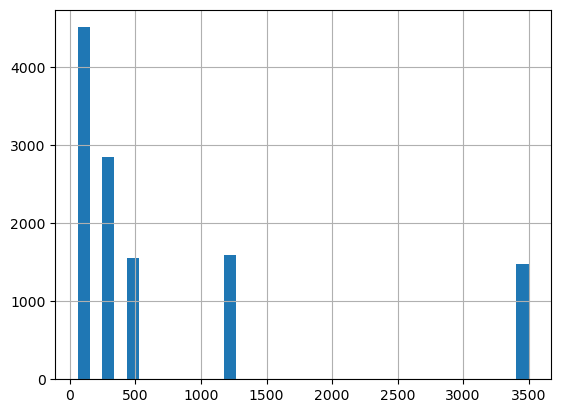

In [80]:
preco_num.hist(bins="auto")

**Avaliação da Coluna: Preço Unitário**

- **Problemas observados:** A coluna não apresenta valores ausentes, porém encontra-se tipada como string na base original. Após conversão para numérico para fins de diagnóstico, não foram identificados valores zero ou negativos. Foram observados valores extremos de preço, os quais são plausíveis no contexto do portfólio de produtos (ex: itens premium).  
- **Impacto analítico:** A tipagem incorreta inviabiliza cálculos financeiros confiáveis (faturamento, ticket médio) e validações de consistência com outras colunas financeiras.  
- **Criticidade:** Alta.  
- **Ação planejada:** Limpeza e conversão da coluna para tipo numérico (float), com tratamento de símbolos monetários e separadores decimais. Manter os valores extremos identificados, uma vez que são coerentes com o contexto de negócio.

### 2.1.6. Quantidade Vendida

>**Objetivo da verificação:**
Avaliar completude, tipagem, validade de domínio (valores positivos) e presença de outliers na coluna Quantidade Vendida.

In [127]:
print(f"Quantidade de valores ausentes na coluna Quantidade Vendida: {df['Quantidade Vendida'].isnull().sum()}")

Quantidade de valores ausentes na coluna Quantidade Vendida: 0


**Verificação de tipagem da coluna Quantidade Vendida:**\
Avaliação do tipo atual da coluna para confirmar conformidade com o tipo esperado (inteiro).

In [83]:
df["Quantidade Vendida"].info()

<class 'pandas.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: Quantidade Vendida
Non-Null Count  Dtype
--------------  -----
12000 non-null  int64
dtypes: int64(1)
memory usage: 93.9 KB


In [84]:
df["Quantidade Vendida"].describe()

count    12000.000000
mean         4.120583
std         12.668784
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max        197.000000
Name: Quantidade Vendida, dtype: float64

>A distribuição da quantidade vendida apresenta valores extremos significativamente superiores ao padrão observado, indicando a presença de outliers que devem ser avaliados quanto à plausibilidade operacional.

**Investigação dos outliers de Quantidade Vendida:**\
Os registros com quantidade vendida igual ao valor máximo observado foram inspecionados para avaliar plausibilidade de negócio e consistência com os campos financeiros associados.

In [86]:
df.loc[df["Quantidade Vendida"]==197]

,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento
2187,1455,2023-04-29 05:51:35.663775850,Calça E,Roupas,120,197,0.03,349.2,Curitiba,Boleto
10680,2390,2023-11-14 00:00:00.000000000,Smartphone A,Eletrônicos,1200,197,0.05,4788.0,Belo Horizonte,Cartão de Crédito


**Investigação qualitativa dos outliers de Quantidade Vendida**

A inspeção dos registros com maior quantidade vendida (197 unidades) revelou inconsistências graves entre o valor total registrado e o valor esperado segundo a regra de negócio $$(Preço Unitário × Quantidade Vendida × (1 − Desconto))$$Em ambos os casos analisados, os valores totais encontram-se em ordem de grandeza incompatível com o volume vendido, caracterizando falha de integridade nos dados transacionais.

**Avaliação da Coluna: Quantidade Vendida**

- **Problemas observados:** Não foram identificados valores ausentes e a coluna encontra-se tipada corretamente como inteiro. Foram identificados **dois registros específicos** com quantidade vendida extremamente elevada (197 unidades) em uma única transação.  
- **Impacto analítico:** Nos dois casos analisados, as quantidades elevadas estão associadas a inconsistências matemáticas entre preço unitário, desconto e valor total, indicando violação de regras básicas de negócio. Além disso, volumes dessa magnitude são pouco plausíveis para produtos de maior valor unitário (ex: smartphones), distorcendo métricas de volume e faturamento.  
- **Criticidade:** Alta.  
- **Ação planejada:** Tratar esses dois registros como outliers não plausíveis e inconsistentes, com correção ou exclusão na etapa de limpeza. Implementar validações automáticas de consistência entre preço unitário, quantidade vendida, desconto e valor total no pipeline de tratamento para prevenir recorrência do problema.

### 2.1.7. Desconto

>**Objetivo da verificação:**
Avaliar completude, tipagem, validade de domínio (intervalo permitido) e presença de valores extremos na coluna Desconto.

In [128]:
print(f"Quantidade de valores ausentes na coluna Desconto: {df['Desconto'].isnull().sum()}")

Quantidade de valores ausentes na coluna Desconto: 0


**Verificação de tipagem da coluna Desconto:**\
Avaliação do tipo atual da coluna para confirmar conformidade com o tipo esperado (numérico contínuo).

In [88]:
df["Desconto"].info()

<class 'pandas.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: Desconto
Non-Null Count  Dtype  
--------------  -----  
12000 non-null  float64
dtypes: float64(1)
memory usage: 93.9 KB


In [89]:
df["Desconto"].describe()

count    12000.000000
mean         0.067605
std          0.070671
min          0.000000
25%          0.030000
50%          0.060000
75%          0.090000
max          0.900000
Name: Desconto, dtype: float64

>Os valores de desconto encontram-se dentro do intervalo esperado [0, 1], não sendo observados valores negativos ou superiores a 100%. Foram identificados descontos elevados (até 90%), os quais, embora válidos do ponto de vista estrutural, podem demandar validação junto à política comercial.

**Avaliação da Coluna: Desconto**

- **Problemas observados:** Não foram identificados valores ausentes e a coluna encontra-se corretamente tipada como numérica. Os valores variam de 0.0 a 0.9, estando matematicamente dentro do intervalo esperado para um percentual de desconto.  
- **Impacto analítico:** A presença de descontos elevados (até 90%) pode impactar significativamente análises de margem e rentabilidade, devendo ser interpretada com cautela sob a ótica de negócio.  
- **Criticidade:** Baixa a Média (dependente da política comercial da empresa).  
- **Ação planejada:** Manter os valores, com monitoramento de descontos extremos e, se necessário, análise específica de campanhas promocionais atípicas.

### 2.1.8. Valor Total

>**Objetivo da verificação:**
Avaliar completude, tipagem, validade de domínio e consistência do valor total em relação à regra de negócio (Preço Unitário × Quantidade Vendida × (1 − Desconto)).

In [129]:
print(f"Quantidade de valores ausentes na coluna Valor Total: {df['Valor Total'].isnull().sum()}")

Quantidade de valores ausentes na coluna Valor Total: 0


**Verificação de tipagem da coluna Valor Total:**
Avaliação do tipo atual da coluna para identificar necessidade de conversão para formato numérico.

In [94]:
df["Valor Total"].info()

<class 'pandas.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: Valor Total
Non-Null Count  Dtype  
--------------  -----  
12000 non-null  float64
dtypes: float64(1)
memory usage: 93.9 KB


In [95]:
df["Valor Total"].describe()

count    12000.000000
mean      2444.549189
std       4280.117970
min         43.144094
25%        291.000000
50%        720.000000
75%       2376.000000
max      52101.470000
Name: Valor Total, dtype: float64

<Axes: >

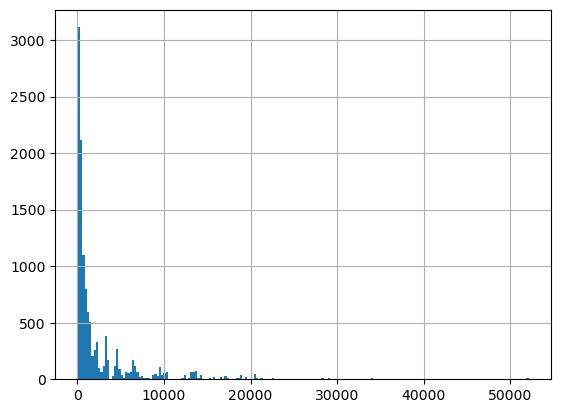

In [98]:
df["Valor Total"].hist(bins = 200)

In [99]:
df.loc[df["Valor Total"]==df["Valor Total"].max()]

,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento
1751,2436,2023-12-13 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,Pix
3997,2436,2023-12-09 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,Pix
4408,2436,2023-11-20 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,Pix
5250,2436,2023-12-18 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,SP,Pix
6332,2436,2023-11-28 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,SP,Pix
7906,2436,2023-09-12 00:00:00.000000000,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,Pix
8149,2436,2023-12-15 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,Pix
8587,2436,2023-12-02 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,NaN
8990,2436,2023-11-15 11:00:55.236824548,Notebook B,Eletrônicos,3500,4,0.0,52101.47,São Paulo,Pix
10929,2436,2023-11-16 11:00:55.236824548,Notebook B,Eletrônicos,"R$ 3.500,00",4,0.0,52101.47,São Paulo,Pix


>**Investigação do outlier de Valor Total:**
A inspeção dos registros com valor total máximo revelou múltiplas ocorrências do mesmo padrão de inconsistência financeira, indicando possível falha de consolidação de dados (duplicação de registros) associada a erro de cálculo do valor total.

In [137]:
tolerancia = 0.01  # tolerância de 1 centavo

df["valor_correto"] = (preco_num * df["Quantidade Vendida"]) * (1 - df["Desconto"])
df["diff_valor_total"] = (df["Valor Total"] - df["valor_correto"]).abs()
df["inconsistente_valor_total"] = df["diff_valor_total"] > tolerancia

print(f"Registros inconsistentes (>|{tolerancia}|): {qtd_inconsistentes}")
print(f"Percentual de registros inconsistentes: {pct_inconsistentes:.2f}%")

Registros inconsistentes (>|0.01|): 3635
Percentual de registros inconsistentes: 30.29%


**Síntese do diagnóstico de integridade financeira**

A validação da regra de negócio do valor total indicou que uma parcela relevante dos registros apresenta divergência entre o valor registrado e o valor esperado $(Preço Unitário × Quantidade Vendida × (1 − Desconto))$, mesmo considerando tolerância de arredondamento. Este achado caracteriza falha sistêmica de integridade dos dados financeiros, com impacto direto sobre métricas de faturamento, ticket médio e análises de performance comercial.

**Avaliação da Coluna: Valor Total**

- **Problemas observados:** A coluna não apresenta valores ausentes e encontra-se corretamente tipada como numérica. Entretanto, foram identificados registros com valores totais inconsistentes em relação à regra de negócio esperada (Preço Unitário × Quantidade Vendida × (1 − Desconto)). Em um caso específico, foi observado um valor total de 52.101,47 para a venda de um Notebook B (preço unitário de 3.500, quantidade 4 e desconto 0), quando o valor esperado seria aproximadamente 14.000.  
- **Impacto analítico:** A presença de valores totais inconsistentes compromete diretamente a confiabilidade de métricas financeiras, como faturamento total, ticket médio e performance por produto. Adicionalmente, este registro específico encontra-se duplicado na base, amplificando artificialmente o impacto do erro nas métricas agregadas.  
- **Criticidade:** Alta.  
- **Ação planejada:** Implementar validações de consistência entre valor total e os campos determinantes (preço unitário, quantidade vendida e desconto). Registros inconsistentes deverão ser corrigidos (quando possível) ou excluídos das análises financeiras agregadas. Registros duplicados exatos deverão ser removidos na etapa de limpeza.

### 2.1.9. Localização

>**Objetivo da verificação:**
Avaliar completude, consistência semântica e padronização dos valores da coluna Localização, visando garantir confiabilidade em análises regionais.

In [138]:
print(f"Quantidade de Localização Faltantes: {df["Localização"].isnull().sum()}")

Quantidade de Localização Faltantes: 467


In [102]:
df["Localização"].value_counts(dropna=False).head(20)

Localização
São Paulo         2830
Rio de Janeiro    2796
Belo Horizonte    1661
Curitiba          1272
Salvador           844
NaN                467
SP                 428
Sao Paulo          416
são paulo          391
curitiba           271
CTBA               260
salvador           187
SSA                177
Name: count, dtype: int64

**Avaliação da Coluna: Localização**

- **Problemas observados:** Foram identificados valores ausentes e fragmentação semântica, com múltiplas representações para a mesma localidade (ex: “São Paulo”, “Sao Paulo”, “são paulo”, “SP”; “Curitiba”, “curitiba”, “CTBA”; “Salvador”, “salvador”, “SSA”). Há inconsistência de padronização de caixa e uso misto de siglas e nomes por extenso.  
- **Impacto analítico:** A fragmentação dos valores de localização compromete análises regionais, consolidações geográficas e rankings de vendas por cidade/estado, levando à subestimação ou superestimação de métricas regionais.  
- **Criticidade:** Média.  
- **Ação planejada:** Normalizar os valores de localização (remoção de acentos, padronização de caixa) e criar um mapeamento de sinônimos/siglas para uma nomenclatura única. Avaliar estratégias de imputação para valores ausentes quando aplicável.

### 2.1.10. Forma de Pagamento

>**Objetivo da verificação:**
Avaliar completude, consistência semântica e padronização dos valores da coluna Forma de Pagamento, visando garantir confiabilidade em análises por meio de pagamento.

In [105]:
print(f"Quantidade de Métodos de Pagamentos Faltantes: {df['Forma de Pagamento'].isnull().sum()}")

Quantidade de Métodos de Pagamentos Faltantes: 483


In [106]:
df["Forma de Pagamento"].value_counts(dropna=False).head(20)

Forma de Pagamento
Cartão de Crédito    5306
Pix                  2687
Cartão de Débito     2309
Boleto               1215
NaN                   483
Name: count, dtype: int64

**Avaliação da Coluna: Forma de Pagamento**

- **Problemas observados:** Foram identificados valores ausentes na coluna Forma de Pagamento. As categorias existentes encontram-se padronizadas, sem fragmentação semântica relevante.  
- **Impacto analítico:** A ausência de informação sobre o meio de pagamento compromete análises de participação por método (ex: Pix vs Cartão), avaliação de custos operacionais (taxas por meio de pagamento) e estudos de comportamento do cliente.  
- **Criticidade:** Média.  
- **Ação planejada:** Avaliar estratégias de imputação para o meio de pagamento com base em padrões históricos (quando aplicável) ou exclusão controlada desses registros em análises específicas por forma de pagamento.

## 2.2. Achados Críticos Encontrados

Nesta seção são consolidados os principais problemas de qualidade de dados identificados na base de vendas do e-commerce, priorizados de acordo com seu impacto analítico e de negócio.

### 🔴 Achados Críticos (Alta Prioridade)

**1. Inconsistência no Valor Total (Violação de Regra de Negócio Financeira)**  
- **Descrição:** Aproximadamente 30% dos registros apresentam divergência entre o valor total registrado e o valor esperado segundo a regra de negócio (Preço Unitário × Quantidade Vendida × (1 − Desconto)). Foram identificados casos com valores em ordem de grandeza incompatível com os campos determinantes, além de registros inconsistentes replicados na base.  
- **Impacto:** Compromete diretamente métricas financeiras (faturamento, ticket médio, receita por produto) e pode levar a decisões equivocadas de negócio.  
- **Ação Prioritária:** Recalcular o valor total durante a etapa de limpeza, corrigir/remover registros inconsistentes e implementar validações automáticas de integridade financeira no pipeline de dados.

**2. Duplicidade de Registros (Linhas Idênticas)**  
- **Descrição:** Foram identificados registros completamente duplicados na base, indicando falhas no processo de extração ou consolidação dos dados do CRM.  
- **Impacto:** Superestimação de métricas de volume e faturamento, além de distorção de indicadores operacionais.  
- **Ação Prioritária:** Remoção de duplicatas exatas na etapa de tratamento dos dados.

**3. Baixa Confiabilidade do Identificador de Venda (ID da Venda)**  
- **Descrição:** O identificador de venda apresenta baixa cardinalidade e múltiplas ocorrências, não se comportando como chave primária confiável.  
- **Impacto:** Dificulta rastreabilidade de pedidos, análises de número de transações e integração com outras fontes de dados.  
- **Ação Prioritária:** Alinhar com stakeholders o significado semântico do ID (pedido vs item de pedido) e definir chave primária adequada para análises transacionais.

### 🟠 Achados Relevantes (Média Prioridade)

**4. Fragmentação Semântica em Localização**  
- **Descrição:** Múltiplas representações para a mesma localidade (ex: siglas, variações de grafia e uso inconsistente de caixa).  
- **Impacto:** Compromete análises regionais e consolidações geográficas.  
- **Ação:** Normalização textual e mapeamento de sinônimos para nomenclatura padronizada.

**5. Dados Ausentes em Campos Categóricos (Categoria e Forma de Pagamento)**  
- **Descrição:** Presença de valores ausentes em colunas relevantes para segmentações de negócio.  
- **Impacto:** Limita análises de mix de produtos e participação por meio de pagamento.  
- **Ação:** Avaliar imputação baseada em padrões históricos ou exclusão controlada em análises específicas.

### 🟢 Achados de Baixa Prioridade

**6. Tipagem Estrutural (Preço Unitário e Data da Venda)**  
- **Descrição:** Colunas originalmente tipadas como string, apesar de representarem valores numéricos e temporais.  
- **Impacto:** Impede análises diretas enquanto não convertidas, mas com baixo risco operacional de correção.  
- **Ação:** Conversão de tipo e validação de formato na etapa de preparação dos dados.

## 3. Conclusão Executiva

A análise exploratória e o diagnóstico de qualidade dos dados da base de vendas do e-commerce evidenciaram que, embora a base seja rica em volume e variáveis relevantes para análises de negócio, ela apresenta problemas estruturais e semânticos que comprometem a confiabilidade de métricas estratégicas, especialmente financeiras.

O achado mais crítico refere-se à **violação da regra de negócio do valor total da venda**, com uma parcela relevante dos registros apresentando inconsistência entre o valor total registrado e o valor esperado a partir de preço unitário, quantidade vendida e desconto. Este problema, aliado à presença de **registros duplicados**, implica risco elevado de distorção de KPIs como faturamento total, ticket médio e performance por produto.

Adicionalmente, foram identificados problemas de **qualidade categórica** (fragmentação semântica em Localização) e **completude** (valores ausentes em Categoria e Forma de Pagamento), os quais afetam análises de segmentação regional e comportamental. Questões estruturais de tipagem (Preço Unitário e Data da Venda) também foram observadas, demandando tratamento prévio antes de qualquer modelagem ou geração de indicadores.

Diante desse cenário, recomenda-se que a base passe por uma **etapa robusta de limpeza, padronização e validação de regras de negócio** antes de ser utilizada para análises gerenciais, relatórios executivos ou modelos analíticos. A implementação de **validações automáticas no pipeline de dados** (ex: checagem de consistência financeira, unicidade de registros e padronização de categorias) é fundamental para prevenir a reincidência dos problemas observados.

Como próximos passos, sugere-se:
- Construção de um pipeline de tratamento de dados (ETL/ELT) com regras explícitas de validação;  
- Reprocessamento histórico da base para correção das inconsistências críticas;  
- Definição conjunta com stakeholders das regras semânticas de identificadores (ex: granularidade do ID da Venda);  
- Desenvolvimento de dashboards e análises apenas sobre a base já tratada e validada.

Este processo garante que as análises subsequentes reflitam de forma fidedigna a realidade operacional e financeira do e-commerce, apoiando decisões estratégicas com maior grau de confiança.